In [77]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import os
import sys
from pathlib import Path
import glob

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from src.plot_flow_pattern_maps import map_garimella

In [2]:
plt.rcParams.update({
    "text.usetex": True,

    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    "ytick.color": "black",
    "xtick.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",

    "axes.linewidth": 0.8,

    "xtick.direction": "in",
    "ytick.direction": "in",
})

# Experimental conditions

In [3]:
silver_path = Path.cwd().parent / 'data/silver_layer/'

silver_confocal_path = Path.cwd().parent / 'data/silver_layer/confocal_runs'
gold_profile_path = Path.cwd().parent / 'data/gold_layer/'

selected_conditions_path = gold_profile_path / 'flow_pattern_map_selected_conditions.pdf'
all_conditions_path = gold_profile_path / 'flow_pattern_map_all_conditions.pdf'

In [4]:

df_confocal = pd.read_pickle(silver_path / 'confocal_results.pkl')
df_experimental = pd.read_pickle(silver_path / 'experimental_results.pkl')

In [5]:
missing_threshold = 50

In [6]:
df_consolidated = pd.merge(df_confocal, df_experimental, on='run_id', how='inner')

In [7]:
CM = 1 / 2.54

FIG_WIDTH_CM = 8.4
FIG_HEIGHT_CM = 7.2
FIG_SIZE = (FIG_WIDTH_CM * CM, FIG_HEIGHT_CM * CM)

In [ ]:
fig1, ax = map_garimella(df_consolidated.loc[df_consolidated['t2_missing_percentage']<missing_threshold])
fig2, ax = map_garimella(df_consolidated)

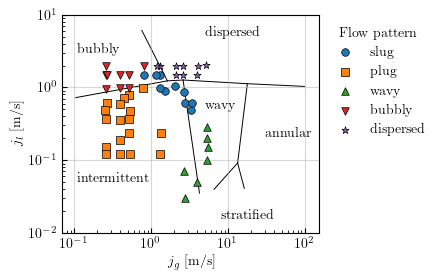

In [12]:
fig1

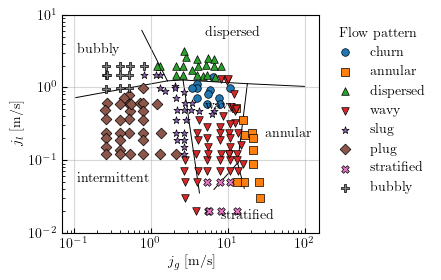

In [13]:
fig2

In [11]:
fig1.savefig(selected_conditions_path, format='pdf', bbox_inches='tight')
fig2.savefig(all_conditions_path, format='pdf', bbox_inches='tight')